<a href="https://colab.research.google.com/github/MojiburRahaman/colab-project/blob/main/clustering/Iris_Clustering_Mojibur_Rahaman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import confusion_matrix, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

iris_data = load_iris()
X = iris_data.data
y = iris_data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-1.468455e-15,-1.823726e-15,-1.610564e-15,-9.473903e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00
25%,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00
50%,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01
75%,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00


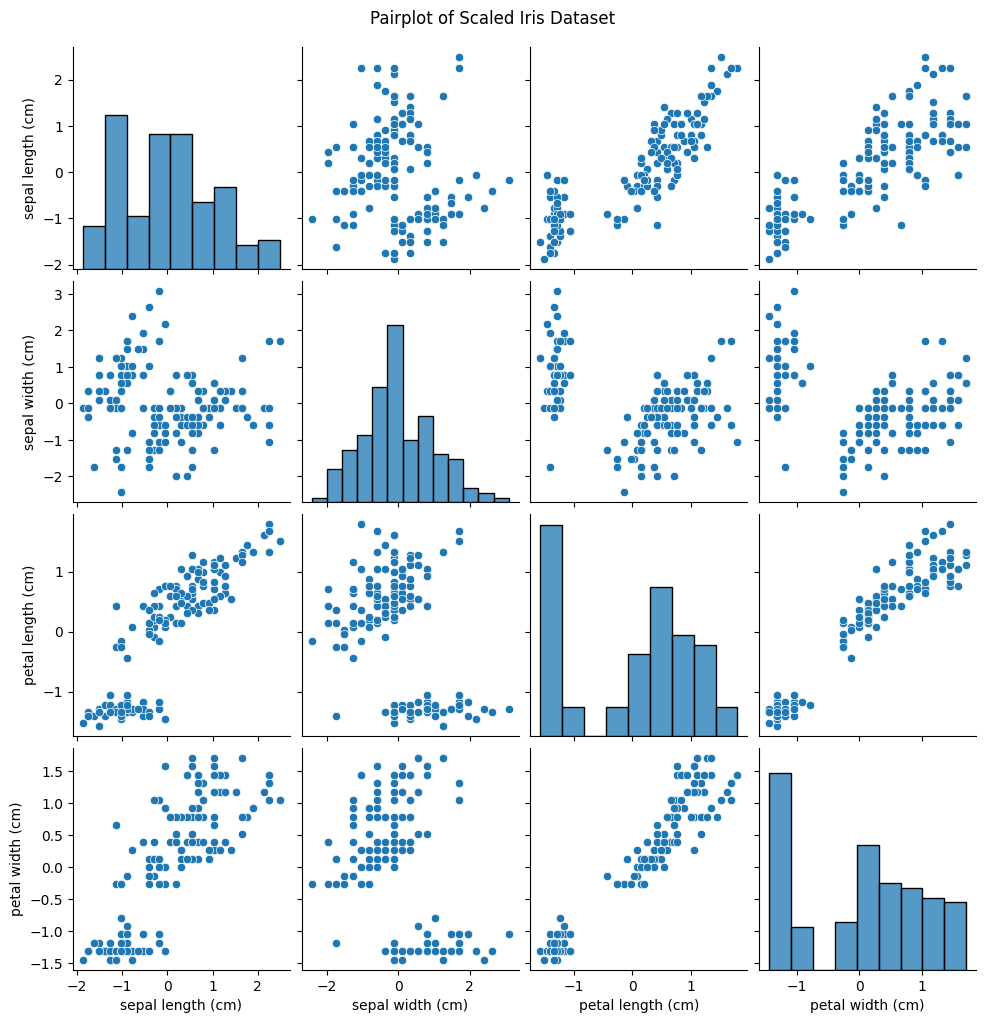

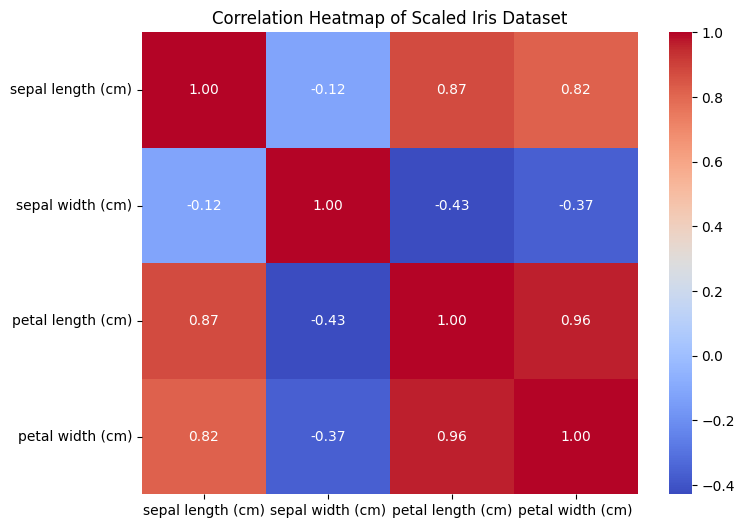

In [ ]:
# Create a DataFrame from the scaled data
df_scaled = pd.DataFrame(X_scaled, columns=iris_data.feature_names)

# Display basic statistics
display(df_scaled.describe())

# Generate a pairplot
sns.pairplot(df_scaled)
plt.suptitle('Pairplot of Scaled Iris Dataset', y=1.02)
plt.show()

# Generate a heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df_scaled.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Scaled Iris Dataset')
plt.show()

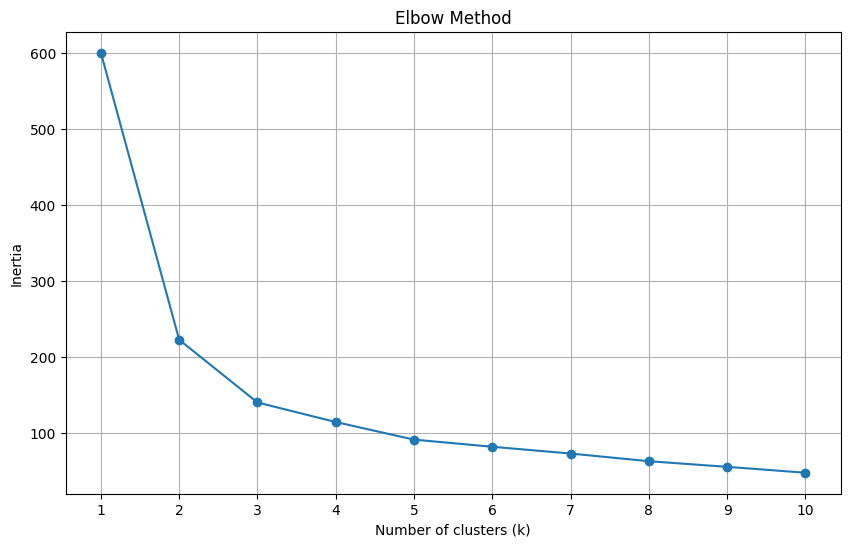

In [ ]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

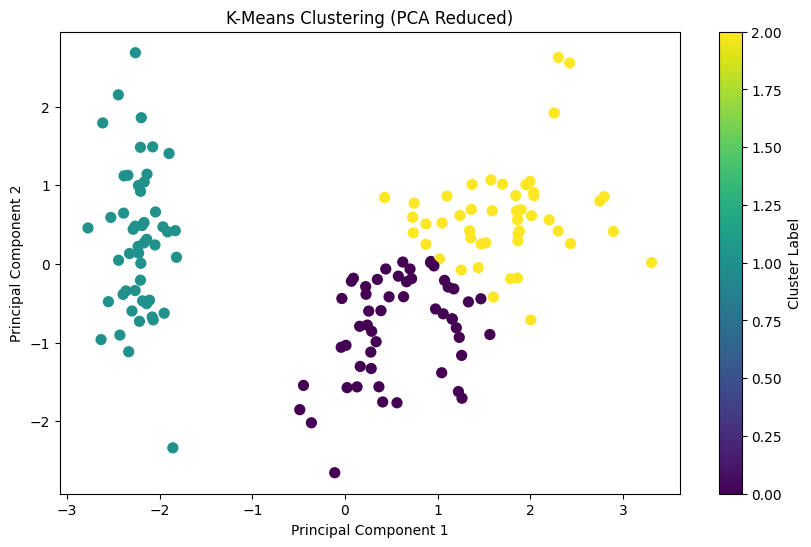

In [ ]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50)
plt.title('K-Means Clustering (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

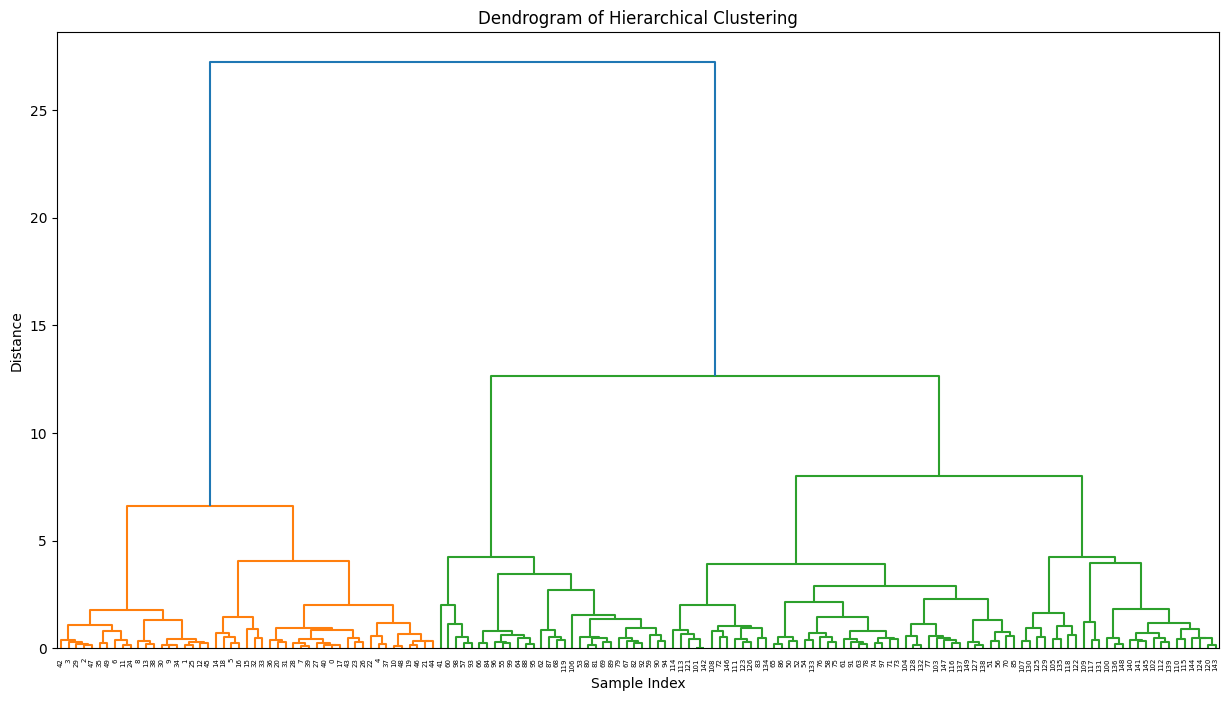

In [ ]:
# Generate the linkage matrix
linked = linkage(df_scaled, 'ward')

# Plot the dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linked,
            orientation='top',
            distance_sort='decreasing',
            show_leaf_counts=True)
plt.title('Dendrogram of Hierarchical Clustering')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

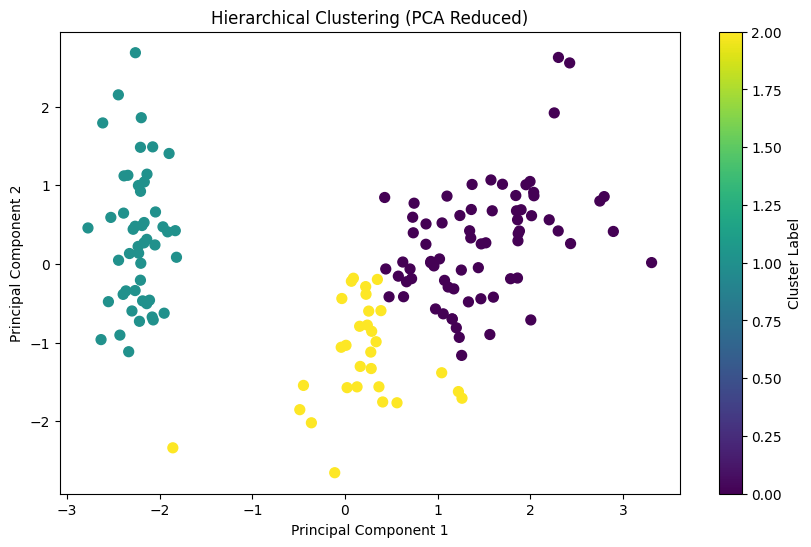

In [ ]:
# Choose the number of clusters based on the dendrogram (longest vertical line not intersected by horizontal lines)
n_clusters = 3

# Apply Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters)
hierarchical_clusters = agg_clustering.fit_predict(df_scaled)

# Reduce dimensionality using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

# Visualize the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_clusters, cmap='viridis', s=50)
plt.title('Hierarchical Clustering (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster Label')
plt.show()

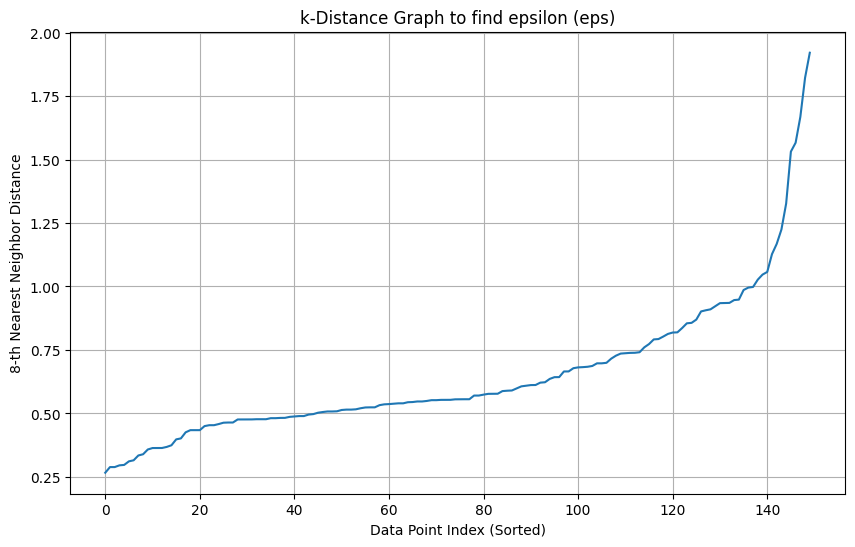

In [ ]:
# Calculate k-distances
n_features = df_scaled.shape[1]
k = 2 * n_features # A common heuristic for min_samples and k for distance calculation
nearest_neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = nearest_neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

# Sort the k-distances
k_distance = distances[:, k-1]
k_distance.sort()

# Plot the k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distance)
plt.title('k-Distance Graph to find epsilon (eps)')
plt.xlabel('Data Point Index (Sorted)')
plt.ylabel(f'{k}-th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

Number of clusters found by DBSCAN: 3
Number of noise points found by DBSCAN: 59


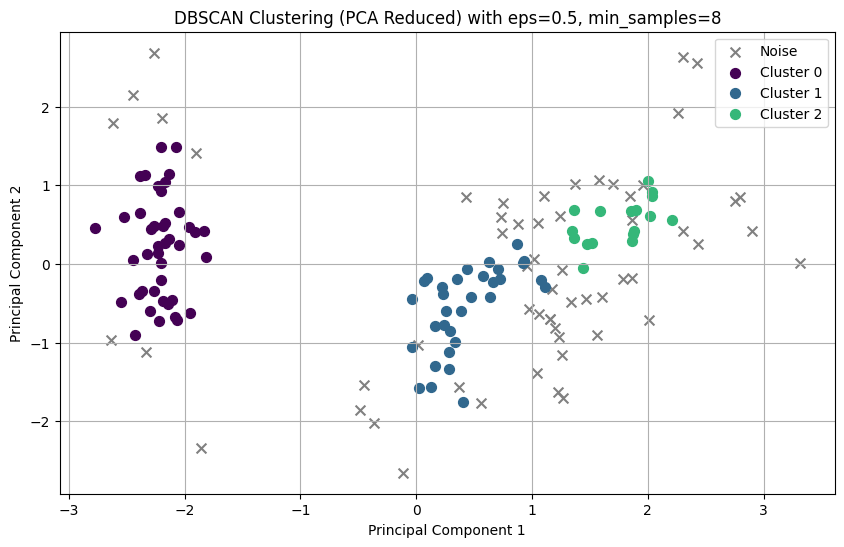

In [ ]:
eps = 0.5
min_samples = k

# Apply DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_clusters = dbscan.fit_predict(df_scaled)

# Identify the number of clusters (excluding noise)
n_clusters_dbscan = len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0)

# Identify the number of noise points
n_noise_points = list(dbscan_clusters).count(-1)

print(f"Number of clusters found by DBSCAN: {n_clusters_dbscan}")
print(f"Number of noise points found by DBSCAN: {n_noise_points}")

# Reduce dimensionality using PCA for visualization
pca = PCA(n_components=2)
X_pca_dbscan = pca.fit_transform(df_scaled)

# Visualize the DBSCAN results
plt.figure(figsize=(10, 6))
# Plot noise points
plt.scatter(X_pca_dbscan[dbscan_clusters == -1, 0], X_pca_dbscan[dbscan_clusters == -1, 1],
            c='gray', marker='x', s=50, label='Noise')
# Plot clustered points
unique_labels = set(dbscan_clusters)
colors = [plt.cm.viridis(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k != -1: # Exclude noise points
        class_member_mask = (dbscan_clusters == k)
        xy = X_pca_dbscan[class_member_mask]
        plt.scatter(xy[:, 0], xy[:, 1], c=[col], s=50, label=f'Cluster {k}')

plt.title(f'DBSCAN Clustering (PCA Reduced) with eps={eps}, min_samples={min_samples}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Compare K-Means clusters to actual species
kmeans_conf_matrix = confusion_matrix(y, clusters)
print("Confusion Matrix (K-Means vs. Actual Species):\n", kmeans_conf_matrix)
kmeans_ari = adjusted_rand_score(y, clusters)
print(f"Adjusted Rand Index (K-Means vs. Actual Species): {kmeans_ari}\n")

# Compare Hierarchical clusters to actual species
hierarchical_conf_matrix = confusion_matrix(y, hierarchical_clusters)
print("Confusion Matrix (Hierarchical Clustering vs. Actual Species):\n", hierarchical_conf_matrix)
hierarchical_ari = adjusted_rand_score(y, hierarchical_clusters)
print(f"Adjusted Rand Index (Hierarchical Clustering vs. Actual Species): {hierarchical_ari}\n")

# Compare DBSCAN clusters to actual species
dbscan_conf_matrix = confusion_matrix(y, dbscan_clusters)
print("Confusion Matrix (DBSCAN vs. Actual Species):\n", dbscan_conf_matrix)
dbscan_ari = adjusted_rand_score(y, dbscan_clusters)
print(f"Adjusted Rand Index (DBSCAN vs. Actual Species): {dbscan_ari}\n")

Confusion Matrix (K-Means vs. Actual Species):
 [[ 0 50  0]
 [39  0 11]
 [14  0 36]]
Adjusted Rand Index (K-Means vs. Actual Species): 0.6201351808870379

Confusion Matrix (Hierarchical Clustering vs. Actual Species):
 [[ 0 49  1]
 [23  0 27]
 [48  0  2]]
Adjusted Rand Index (Hierarchical Clustering vs. Actual Species): 0.6153229932145449

Confusion Matrix (DBSCAN vs. Actual Species):
 [[ 0  0  0  0]
 [ 8 42  0  0]
 [19  0 30  1]
 [32  0  2 16]]
Adjusted Rand Index (DBSCAN vs. Actual Species): 0.4435911609203647

